In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

np.random.seed(224)
tf.random.set_seed(224)

print('TensorFlow versija:', tf.__version__)

/Users/robertajurpalyte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow versija: 2.20.0


In [2]:
DUOMENU_KELIAS = '/Users/robertajurpalyte/Desktop/uni/Dirbtinio intelekto pagrindai/dip/DSL-StrongPasswordData.csv'

df = pd.read_csv(DUOMENU_KELIAS)
print('Duomenų forma:', df.shape)
print('\nPirmosios eilutės:')
df.head()

Duomenų forma: (20400, 34)

Pirmosios eilutės:


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [3]:
# Pasirenkame 30 naudotojų ir 1 sesiją (pagal užduotį)
SESIJA = 1
NAUDOTOJU_SK = 30

# Pasirenkame pirmus 30 naudotojų
naudotojai = df['subject'].unique()[:NAUDOTOJU_SK]
print(f'Pasirinkti naudotojai: {naudotojai}')

# Filtruojame: tik pasirinkta sesija ir naudotojai
df_filtras = df[
    (df['sessionIndex'] == SESIJA) &
    (df['subject'].isin(naudotojai))
].copy()

print(f'\nĮrašų skaičius po filtravimo: {len(df_filtras)}')
print(f'Įrašų kiekis kiekvienam naudotojui:')
print(df_filtras['subject'].value_counts().sort_index())

Pasirinkti naudotojai: ['s002' 's003' 's004' 's005' 's007' 's008' 's010' 's011' 's012' 's013'
 's015' 's016' 's017' 's018' 's019' 's020' 's021' 's022' 's024' 's025'
 's026' 's027' 's028' 's029' 's030' 's031' 's032' 's033' 's034' 's035']

Įrašų skaičius po filtravimo: 1500
Įrašų kiekis kiekvienam naudotojui:
subject
s002    50
s003    50
s004    50
s005    50
s007    50
s008    50
s010    50
s011    50
s012    50
s013    50
s015    50
s016    50
s017    50
s018    50
s019    50
s020    50
s021    50
s022    50
s024    50
s025    50
s026    50
s027    50
s028    50
s029    50
s030    50
s031    50
s032    50
s033    50
s034    50
s035    50
Name: count, dtype: int64


In [4]:
# Požymių stulpeliai (31 laiko eilutės požymis, be subject/sessionIndex/rep)
pozymiai = [k for k in df_filtras.columns if k not in ['subject', 'sessionIndex', 'rep']]
print(f'Požymių skaičius: {len(pozymiai)}')

# X – požymiai, y – klasės
X = df_filtras[pozymiai].values  # forma: (1500, 31)
y_str = df_filtras['subject'].values

# Klasių užkodavimas į skaičius (s002->0, s003->1, ...)
le = LabelEncoder()
y = le.fit_transform(y_str)
print(f'Klasių skaičius: {len(le.classes_)}')
print(f'X forma: {X.shape}, y forma: {y.shape}')

# Perskirstymas 80:10:10 pagal kiekvieną klasę (stratified)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'\nMokymo:     {X_train.shape[0]} įrašų')
print(f'Validavimo: {X_val.shape[0]} įrašų')
print(f'Testavimo:  {X_test.shape[0]} įrašų')

# 1D CNN reikalauja formos (samples, timesteps, features)
# Mūsų atveju: (samples, 31, 1)
X_train = X_train.reshape(-1, 31, 1)
X_val   = X_val.reshape(-1, 31, 1)
X_test  = X_test.reshape(-1, 31, 1)

print(f'\nX_train forma po reshape: {X_train.shape}')

Požymių skaičius: 31
Klasių skaičius: 30
X forma: (1500, 31), y forma: (1500,)

Mokymo:     1200 įrašų
Validavimo: 150 įrašų
Testavimo:  150 įrašų

X_train forma po reshape: (1200, 31, 1)


In [5]:
KLASIU_SK = 30

def mokyti_modeli(modelis, epochu_sk=30, pavadinimas='Modelis'):
    print(f'\n{"="*50}')
    print(f'Mokomas: {pavadinimas}')
    print(f'{"="*50}')
    modelis.summary()

    istorija = modelis.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochu_sk,
        batch_size=32,
        verbose=1
    )
    return istorija

def braizyt_rezultatus(istorija, pavadinimas='Modelis'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(istorija.history['loss'],     label='Mokymas',    color='steelblue')
    axes[0].plot(istorija.history['val_loss'], label='Validavimas', color='orange')
    axes[0].set_title(f'{pavadinimas} – Paklaida')
    axes[0].set_xlabel('Epocha')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(istorija.history['accuracy'],     label='Mokymas',    color='steelblue')
    axes[1].plot(istorija.history['val_accuracy'], label='Validavimas', color='orange')
    axes[1].set_title(f'{pavadinimas} – Tikslumas')
    axes[1].set_xlabel('Epocha')
    axes[1].set_ylabel('Tikslumas')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def ivertinti_ir_cm(modelis, pavadinimas='Modelis'):
    nusp = np.argmax(modelis.predict(X_test), axis=1)
    tikslumas = np.mean(nusp == y_test)
    print(f'\n{pavadinimas} – Testavimo tikslumas: {tikslumas:.4f}')

    cm = confusion_matrix(y_test, nusp)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f'{pavadinimas} – Klasifikavimo matrica')
    plt.tight_layout()
    plt.show()

    return tikslumas

print('Pagalbinės funkcijos paruoštos ✓')

Pagalbinės funkcijos paruoštos ✓



Mokomas: Arch1 – Paprasta


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0397 - loss: 3.3908 - val_accuracy: 0.0333 - val_loss: 3.3486
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0343 - loss: 3.3094 - val_accuracy: 0.0667 - val_loss: 3.2245
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1052 - loss: 3.1305 - val_accuracy: 0.2533 - val_loss: 2.9884
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2519 - loss: 2.8021 - val_accuracy: 0.2933 - val_loss: 2.7609
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3059 - loss: 2.5015 - val_accuracy: 0.2867 - val_loss: 2.5900
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3532 - loss: 2.2827 - val_accuracy: 0.3667 - val_loss: 2.4337
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3904 - loss: 2.1088 - val_accuracy: 0.4000 - val_loss: 2.3051
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4513 - loss: 1.9526 - val_accuracy: 0.4400 - val_loss:

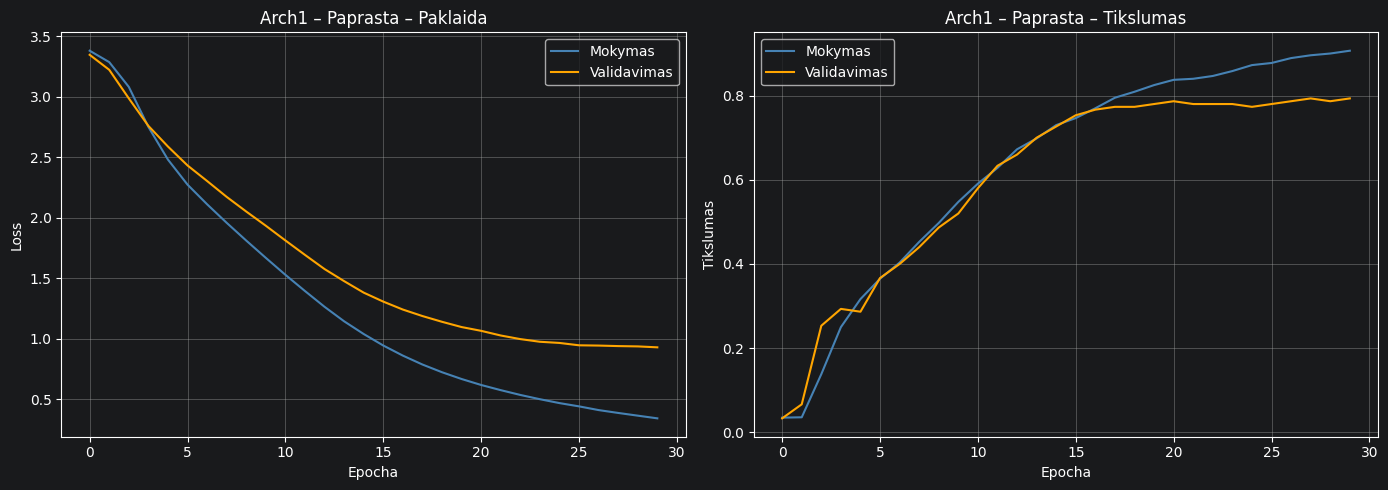

In [7]:
def sukurti_arch1(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    """
    Architektūra 1: 2 Conv1D blokai + 1 tankus sluoksnis.
    Conv1D slenkasi per laiko eilutę ir ieško lokalių šablonų.
    """
    modelis = keras.Sequential(name='Arch1_Paprasta')
    modelis.add(layers.Input(shape=(31, 1)))

    # 1 konvoliucinis blokas: 32 filtrai, branduolys=3
    modelis.add(layers.Conv1D(32, kernel_size=3, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling1D(pool_size=2))

    # 2 konvoliucinis blokas: 64 filtrai
    modelis.add(layers.Conv1D(64, kernel_size=3, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling1D(pool_size=2))

    # Klasifikavimo galva
    modelis.add(layers.Flatten())
    modelis.add(layers.Dense(64, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    # 30 klasių -> softmax
    modelis.add(layers.Dense(KLASIU_SK, activation='softmax'))

    modelis.compile(
        optimizer=optimizatorius,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch1 = sukurti_arch1()
hist1 = mokyti_modeli(arch1, epochu_sk=30, pavadinimas='Arch1 – Paprasta')
braizyt_rezultatus(hist1, 'Arch1 – Paprasta')


Mokomas: Arch2 – Vidutinė


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 31, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 7, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,622 (650.87 KB)

 Trainable params: 166,622 (650.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0353 - loss: 3.3993 - val_accuracy: 0.0333 - val_loss: 3.3625
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0514 - loss: 3.3190 - val_accuracy: 0.0533 - val_loss: 3.2481
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0730 - loss: 3.1236 - val_accuracy: 0.1267 - val_loss: 3.0574
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1152 - loss: 2.9372 - val_accuracy: 0.1067 - val_loss: 2.9360
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1028 - loss: 2.8328 - val_accuracy: 0.1800 - val_loss: 2.8462
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1285 - loss: 2.7499 - val_accuracy: 0.2267 - val_loss: 2.7650
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1529 - loss: 2.6691 - val_accuracy: 0.2200 - val_loss: 2.6893
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1871 - loss: 2.5861 - val_accuracy: 0.2467 - val_loss:

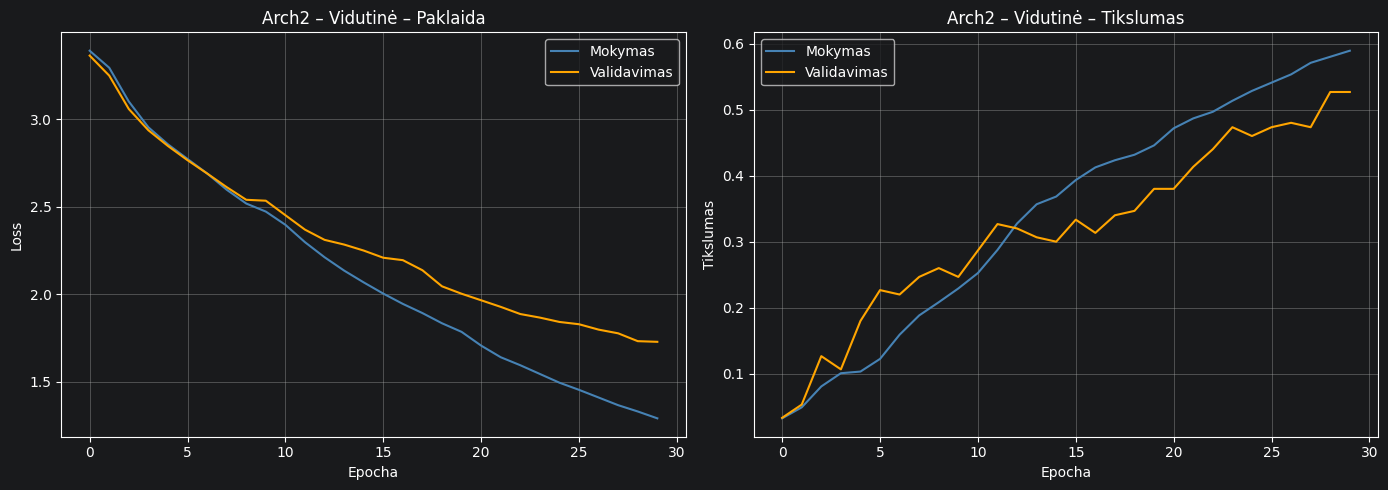

In [9]:
def sukurti_arch2(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    """
    Architektūra 2: 3 Conv1D blokai + 2 tanki sluoksniai.
    """
    modelis = keras.Sequential(name='Arch2_Vidutine')
    modelis.add(layers.Input(shape=(31, 1)))

    # 1 blokas: 64 filtrai
    modelis.add(layers.Conv1D(64, kernel_size=3, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling1D(pool_size=2))

    # 2 blokas: 128 filtrai
    modelis.add(layers.Conv1D(128, kernel_size=3, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling1D(pool_size=2))

    # 3 blokas: 256 filtrai
    modelis.add(layers.Conv1D(256, kernel_size=3, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.GlobalAveragePooling1D())

    # Klasifikavimo galva
    modelis.add(layers.Dense(128, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(64, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(KLASIU_SK, activation='softmax'))

    modelis.compile(
        optimizer=optimizatorius,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch2 = sukurti_arch2()
hist2 = mokyti_modeli(arch2, epochu_sk=30, pavadinimas='Arch2 – Vidutinė')
braizyt_rezultatus(hist2, 'Arch2 – Vidutinė')


Mokomas: Arch3 – Platus branduolys


Model: "Arch3_PlatusKernel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 31, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 15, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,854 (241.62 KB)

 Trainable params: 61,854 (241.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0334 - loss: 3.3975 - val_accuracy: 0.0333 - val_loss: 3.3660
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0370 - loss: 3.3374 - val_accuracy: 0.0600 - val_loss: 3.2771
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0688 - loss: 3.2144 - val_accuracy: 0.0600 - val_loss: 3.1409
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0925 - loss: 3.0526 - val_accuracy: 0.1067 - val_loss: 3.0517
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1033 - loss: 2.9558 - val_accuracy: 0.1200 - val_loss: 3.0103
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1099 - loss: 2.9005 - val_accuracy: 0.1467 - val_loss: 2.9772
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1331 - loss: 2.8556 - val_accuracy: 0.1533 - val_loss: 2.9464
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1430 - loss: 2.8170 - val_accuracy: 0.1667 - val_loss

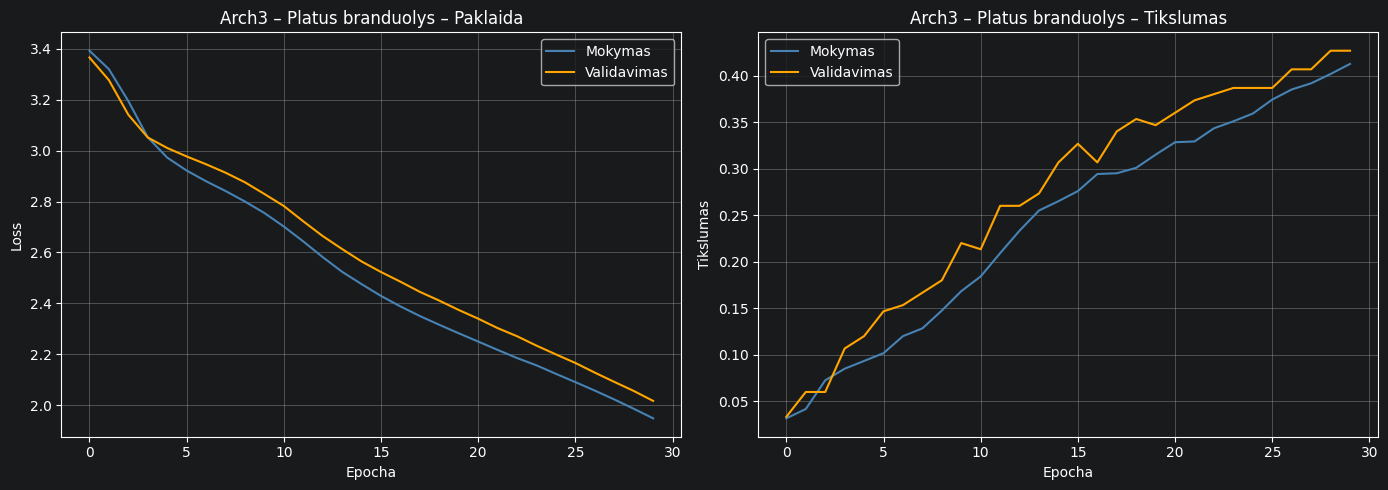

In [11]:
def sukurti_arch3(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    """
    Architektūra 3: 2 Conv1D blokai su didesniu branduoliu (kernel=5)
    + GlobalAveragePooling. Didesnis branduolys mato platesnį kontekstą.
    """
    modelis = keras.Sequential(name='Arch3_PlatusKernel')
    modelis.add(layers.Input(shape=(31, 1)))

    # 1 blokas: kernel_size=5 – mato platesnį laiko langą
    modelis.add(layers.Conv1D(64, kernel_size=5, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling1D(pool_size=2))

    # 2 blokas: kernel_size=5
    modelis.add(layers.Conv1D(128, kernel_size=5, padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.GlobalAveragePooling1D())

    # Klasifikavimo galva
    modelis.add(layers.Dense(128, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(KLASIU_SK, activation='softmax'))

    modelis.compile(
        optimizer=optimizatorius,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch3 = sukurti_arch3()
hist3 = mokyti_modeli(arch3, epochu_sk=30, pavadinimas='Arch3 – Platus branduolys')
braizyt_rezultatus(hist3, 'Arch3 – Platus branduolys')


Mokomas: Dropout=0.0


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0403 - loss: 3.4012 - val_accuracy: 0.0533 - val_loss: 3.3761
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0629 - loss: 3.3681 - val_accuracy: 0.1200 - val_loss: 3.3356
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0672 - loss: 3.3293 - val_accuracy: 0.1133 - val_loss: 3.2562
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0856 - loss: 3.2277 - val_accuracy: 0.1933 - val_loss: 3.1074
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1523 - loss: 3.0940 - val_accuracy: 0.2800 - val_loss: 2.9424
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1722 - loss: 2.9684 - val_accuracy: 0.3067 - val_loss: 2.8105
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2066 - loss: 2.8279 - val_accuracy: 0.3667 - val_loss: 2.6524
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2182 - loss: 2.7248 - val_accuracy: 0.3867 - val_loss:

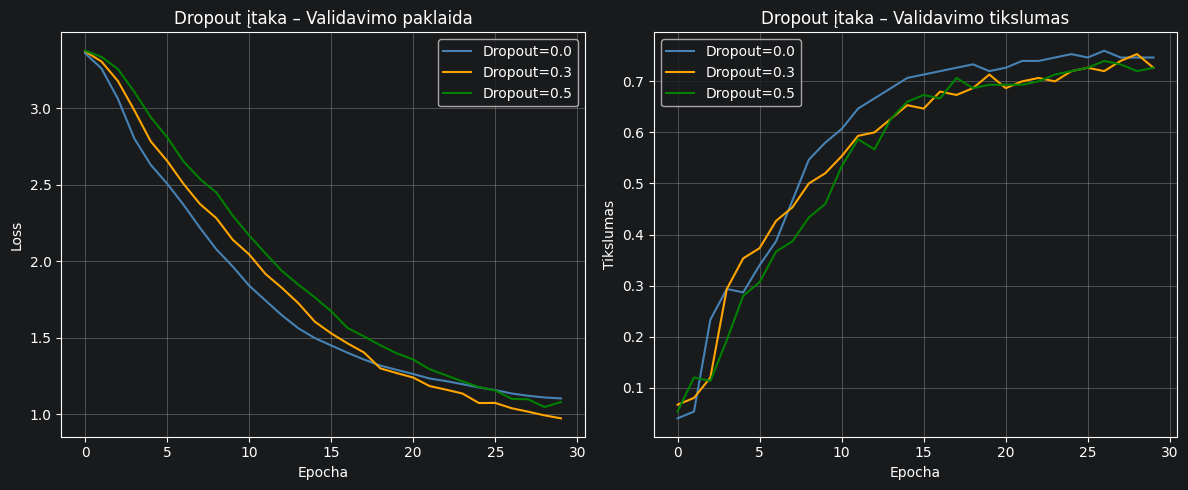

In [12]:
dropout_reiksmes = [0.0, 0.3, 0.5]
dropout_rezultatai = {}
spalvos = ['steelblue', 'orange', 'green']

for dp in dropout_reiksmes:
    m = sukurti_arch1(dropout_tikimybe=dp)
    h = mokyti_modeli(m, epochu_sk=30, pavadinimas=f'Dropout={dp}')
    dropout_rezultatai[dp] = h

plt.figure(figsize=(12, 5))
for (dp, h), spalva in zip(dropout_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=f'Dropout={dp}', color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=f'Dropout={dp}', color=spalva)

plt.subplot(1, 2, 1)
plt.title('Dropout įtaka – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Dropout įtaka – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Be BatchNorm


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,406 (146.12 KB)

 Trainable params: 37,214 (145.37 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1180 - loss: 3.3297 - val_accuracy: 0.0467 - val_loss: 3.3742
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3497 - loss: 2.5568 - val_accuracy: 0.0333 - val_loss: 3.4078
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5371 - loss: 1.9290 - val_accuracy: 0.0400 - val_loss: 3.5339
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6665 - loss: 1.3713 - val_accuracy: 0.0800 - val_loss: 3.8149
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7555 - loss: 0.9651 - val_accuracy: 0.0400 - val_loss: 4.2157
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8312 - loss: 0.6978 - val_accuracy: 0.0533 - val_loss: 4.6523
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8754 - loss: 0.5299 - val_accuracy: 0.0667 - val_loss: 5.0757
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9048 - loss: 0.4140 - val_accuracy: 0.0733 - val_loss:

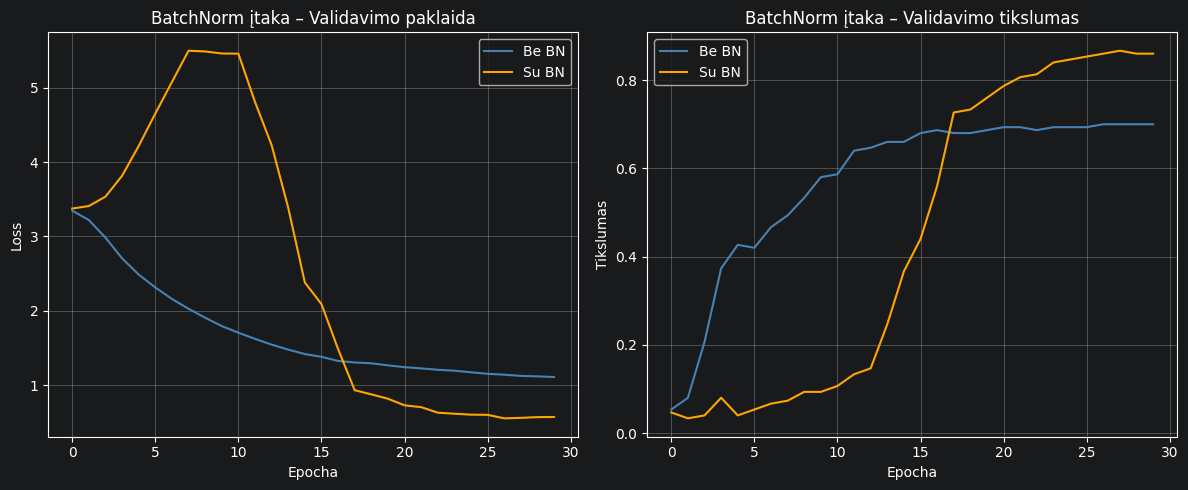

In [13]:
m_be_bn = sukurti_arch1(batch_norm=False)
m_su_bn = sukurti_arch1(batch_norm=True)

h_be_bn = mokyti_modeli(m_be_bn, epochu_sk=30, pavadinimas='Be BatchNorm')
h_su_bn = mokyti_modeli(m_su_bn, epochu_sk=30, pavadinimas='Su BatchNorm')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_be_bn.history['val_loss'], label='Be BN', color='steelblue')
plt.plot(h_su_bn.history['val_loss'], label='Su BN', color='orange')
plt.title('BatchNorm įtaka – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(h_be_bn.history['val_accuracy'], label='Be BN', color='steelblue')
plt.plot(h_su_bn.history['val_accuracy'], label='Su BN', color='orange')
plt.title('BatchNorm įtaka – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Aktyvacija=relu


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0464 - loss: 3.3824 - val_accuracy: 0.0400 - val_loss: 3.2891
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1022 - loss: 3.2058 - val_accuracy: 0.3267 - val_loss: 2.9555
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2884 - loss: 2.7634 - val_accuracy: 0.4400 - val_loss: 2.5868
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4009 - loss: 2.3274 - val_accuracy: 0.5200 - val_loss: 2.3286
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4958 - loss: 2.0133 - val_accuracy: 0.5400 - val_loss: 2.1096
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5455 - loss: 1.7432 - val_accuracy: 0.5800 - val_loss: 1.9082
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6124 - loss: 1.5125 - val_accuracy: 0.6067 - val_loss: 1.7362
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6676 - loss: 1.3170 - val_accuracy: 0.6333 - val_loss:

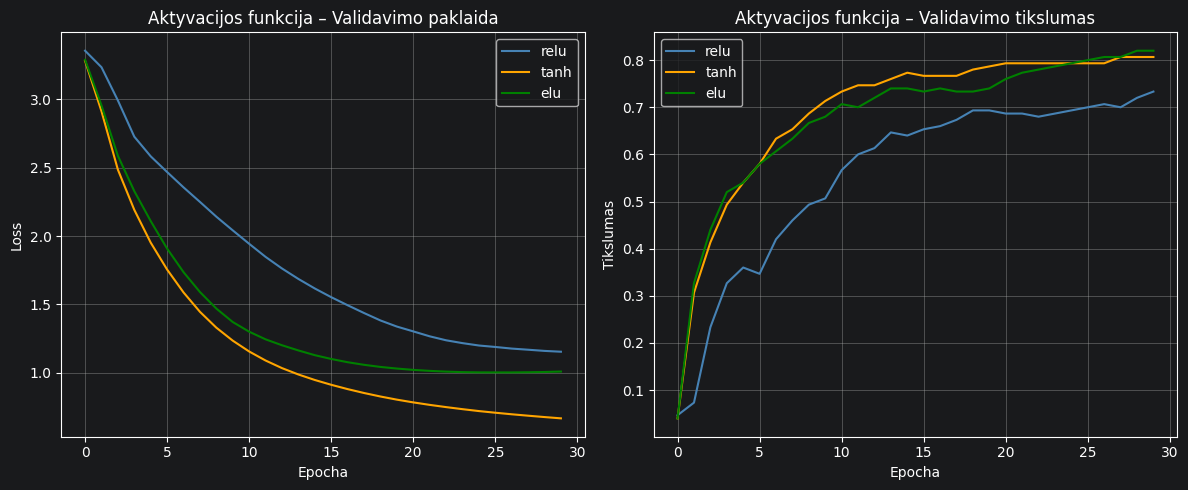

In [14]:
aktyvacijos = ['relu', 'tanh', 'elu']
aktyvacijos_rezultatai = {}
spalvos = ['steelblue', 'orange', 'green']

for akt in aktyvacijos:
    m = sukurti_arch1(aktyvacija=akt)
    h = mokyti_modeli(m, epochu_sk=30, pavadinimas=f'Aktyvacija={akt}')
    aktyvacijos_rezultatai[akt] = h

plt.figure(figsize=(12, 5))

for (akt, h), spalva in zip(aktyvacijos_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=akt, color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=akt, color=spalva)

plt.subplot(1, 2, 1)
plt.title('Aktyvacijos funkcija – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Aktyvacijos funkcija – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Optimizatorius=adam


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_34 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,022 (144.62 KB)

 Trainable params: 37,022 (144.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0279 - loss: 3.3807 - val_accuracy: 0.0333 - val_loss: 3.3232
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0402 - loss: 3.2785 - val_accuracy: 0.1067 - val_loss: 3.2132
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1100 - loss: 3.1357 - val_accuracy: 0.2200 - val_loss: 3.0883
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2264 - loss: 2.9620 - val_accuracy: 0.2667 - val_loss: 2.9636
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2911 - loss: 2.7885 - val_accuracy: 0.3200 - val_loss: 2.8462
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3127 - loss: 2.6330 - val_accuracy: 0.3533 - val_loss: 2.7429
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3214 - loss: 2.5085 - val_accuracy: 0.3600 - val_loss: 2.6596
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3349 - loss: 2.4050 - val_accuracy: 0.3933 - val_loss:

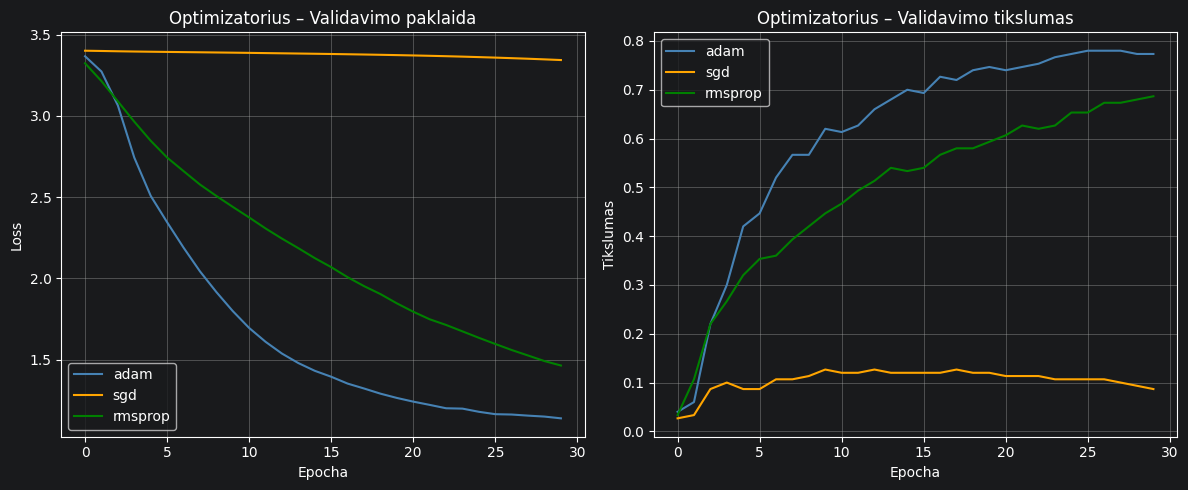

In [15]:
optimizatoriai = ['adam', 'sgd', 'rmsprop']
optim_rezultatai = {}
spalvos = ['steelblue', 'orange', 'green']

for opt in optimizatoriai:
    m = sukurti_arch1(aktyvacija='relu', optimizatorius=opt)
    h = mokyti_modeli(m, epochu_sk=30, pavadinimas=f'Optimizatorius={opt}')
    optim_rezultatai[opt] = h

plt.figure(figsize=(12, 5))

for (opt, h), spalva in zip(optim_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=opt, color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=opt, color=spalva)

plt.subplot(1, 2, 1)
plt.title('Optimizatorius – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Optimizatorius – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Geriausias modelis


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_36 (Conv1D)              │ (None, 31, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,406 (146.12 KB)

 Trainable params: 37,214 (145.37 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1423 - loss: 3.1544 - val_accuracy: 0.1200 - val_loss: 3.2931
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4778 - loss: 2.1548 - val_accuracy: 0.1067 - val_loss: 3.2408
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6670 - loss: 1.6224 - val_accuracy: 0.1000 - val_loss: 3.2654
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7668 - loss: 1.2356 - val_accuracy: 0.0933 - val_loss: 3.3896
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 0.9627 - val_accuracy: 0.0933 - val_loss: 3.5607
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8658 - loss: 0.7678 - val_accuracy: 0.0867 - val_loss: 3.7217
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8958 - loss: 0.6226 - val_accuracy: 0.0933 - val_loss: 3.8250
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9092 - loss: 0.5143 - val_accuracy: 0.1133 - val_loss:

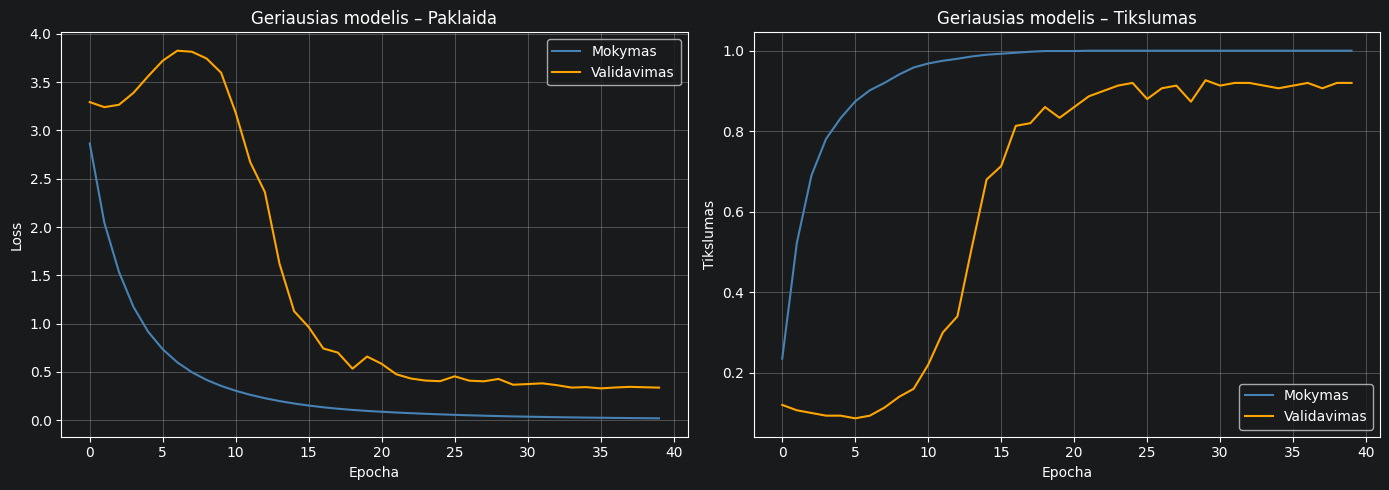

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Geriausias modelis – Testavimo tikslumas: 0.9000


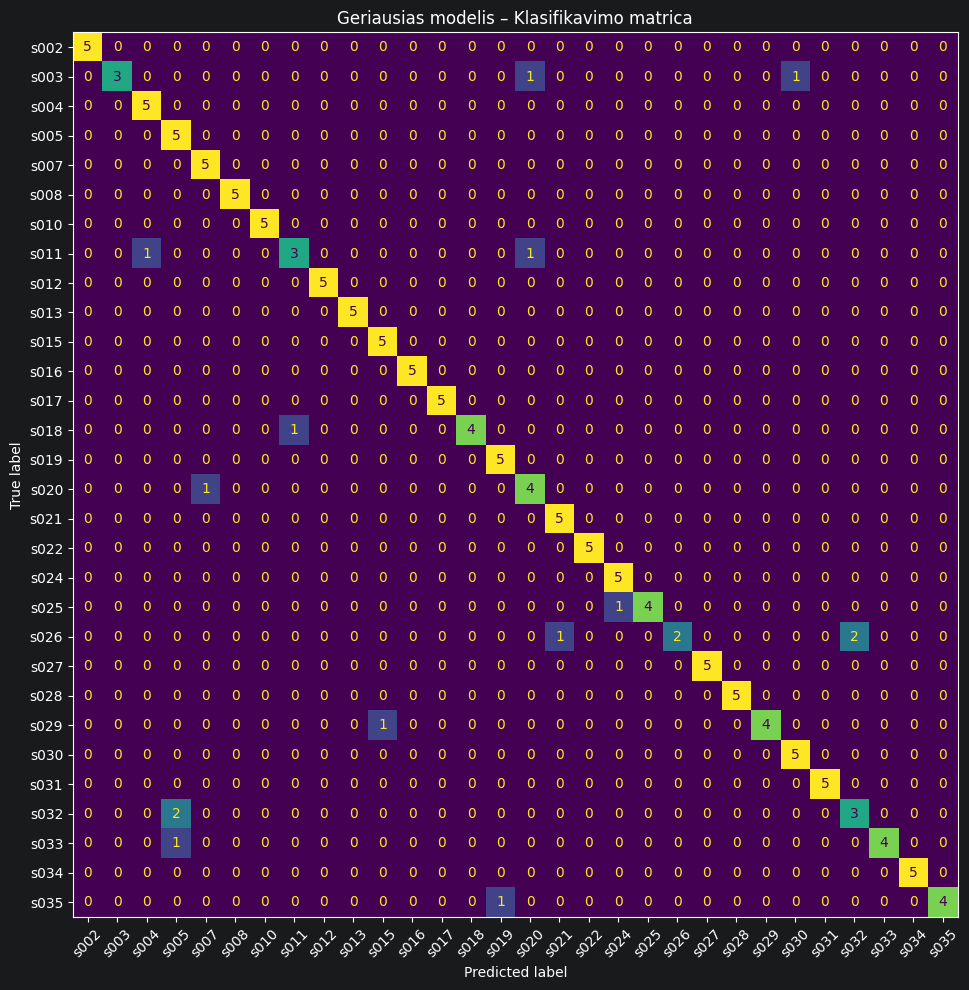

np.float64(0.9)

In [16]:
geriausias_modelis = sukurti_arch1(
    aktyvacija='tanh',
    optimizatorius='adam',
    dropout_tikimybe=0.0,
    batch_norm=True
)

hist_geriausias = mokyti_modeli(geriausias_modelis, epochu_sk=40,
                                pavadinimas='Geriausias modelis')
braizyt_rezultatus(hist_geriausias, 'Geriausias modelis')
ivertinti_ir_cm(geriausias_modelis, 'Geriausias modelis')

In [17]:
# Pasirenkame 30 atsitiktinių testavimo įrašų (po vieną iš kiekvienos klasės)
np.random.seed(42)
pasirinkti_indeksai = []
for klase in range(KLASIU_SK):
    klases_indeksai = np.where(y_test == klase)[0]
    if len(klases_indeksai) > 0:
        pasirinkti_indeksai.append(np.random.choice(klases_indeksai))

X_pavyzdziai = X_test[pasirinkti_indeksai]
y_tikros     = y_test[pasirinkti_indeksai]
y_nuspetos   = np.argmax(geriausias_modelis.predict(X_pavyzdziai, verbose=0), axis=1)

print(f'{"Nr.":<5} {"Tikroji klasė":<18} {"Nustatyta klasė":<18} {"Įvertinimas"}')
print('-' * 55)
for i, (tikra, nusp) in enumerate(zip(y_tikros, y_nuspetos)):
    tikra_str = le.classes_[tikra]
    nusp_str  = le.classes_[nusp]
    ivert     = 'Teisingas' if tikra == nusp else 'Neteisingas'
    print(f'{i+1:<5} {tikra_str:<18} {nusp_str:<18} {ivert}')

teisingi = np.sum(y_tikros == y_nuspetos)
print(f'\nTeisingai suklasifikuota: {teisingi} iš {len(pasirinkti_indeksai)}')

Nr.   Tikroji klasė      Nustatyta klasė    Įvertinimas
-------------------------------------------------------
1     s002               s002               Teisingas
2     s003               s030               Neteisingas
3     s004               s004               Teisingas
4     s005               s005               Teisingas
5     s007               s007               Teisingas
6     s008               s008               Teisingas
7     s010               s010               Teisingas
8     s011               s020               Neteisingas
9     s012               s012               Teisingas
10    s013               s013               Teisingas
11    s015               s015               Teisingas
12    s016               s016               Teisingas
13    s017               s017               Teisingas
14    s018               s011               Neteisingas
15    s019               s019               Teisingas
16    s020               s020               Teisingas
17    s021        